<a href="https://colab.research.google.com/github/chaeyun050821-sketch/20241263/blob/main/Assignment_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 09 - GRAPH
20241263 이채윤


#1-1) 음식점을 그래프로 그리기

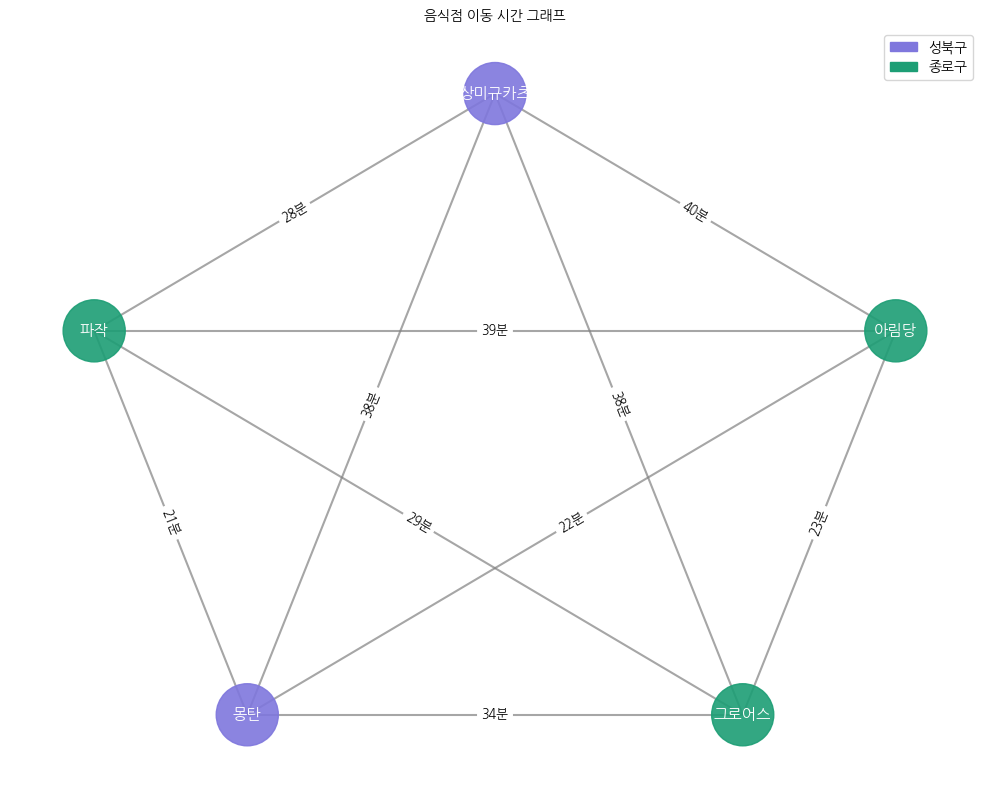

In [ ]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

# 경로로 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

matplotlib.rcParams['font.family'] = prop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False

import networkx as nx
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Patch

restaurants = ['상미규카츠', '파작', '몽탄', '그로어스', '아림당']
gu = {
    '상미규카츠': '성북구', '몽탄': '성북구',
    '파작': '종로구', '그로어스': '종로구', '아림당': '종로구'
}

raw = {
    ('상미규카츠','파작'): 23, ('파작','상미규카츠'): 32,
    ('상미규카츠','몽탄'): 42, ('몽탄','상미규카츠'): 35,
    ('상미규카츠','그로어스'): 39, ('그로어스','상미규카츠'): 38,
    ('상미규카츠','아림당'): 43, ('아림당','상미규카츠'): 38,
    ('파작','몽탄'): 22, ('몽탄','파작'): 20,
    ('파작','그로어스'): 31, ('그로어스','파작'): 27,
    ('파작','아림당'): 44, ('아림당','파작'): 34,
    ('몽탄','그로어스'): 37, ('그로어스','몽탄'): 30,
    ('몽탄','아림당'): 25, ('아림당','몽탄'): 19,
    ('그로어스','아림당'): 24, ('아림당','그로어스'): 22,
}

G = nx.Graph()
G.add_nodes_from(restaurants)
pairs = [
    ('상미규카츠','파작'), ('상미규카츠','몽탄'), ('상미규카츠','그로어스'), ('상미규카츠','아림당'),
    ('파작','몽탄'), ('파작','그로어스'), ('파작','아림당'),
    ('몽탄','그로어스'), ('몽탄','아림당'),
    ('그로어스','아림당'),
]
for a, b in pairs:
    weight = round((raw[(a,b)] + raw[(b,a)]) / 2)
    G.add_edge(a, b, weight=weight)

pos = {}
for i, r in enumerate(restaurants):
    angle = math.pi/2 + 2*math.pi*i/5
    pos[r] = (math.cos(angle), math.sin(angle))

colors = ['#7F77DD' if gu[n]=='성북구' else '#1D9E75' for n in G.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=2000, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=11, font_color='white', font_weight='bold', font_family=prop.get_name())
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5, alpha=0.7)
edge_labels = {k: f"{v}분" for k, v in nx.get_edge_attributes(G, 'weight').items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_family=prop.get_name())

legend = [Patch(color='#7F77DD', label='성북구'), Patch(color='#1D9E75', label='종로구')]
plt.legend(handles=legend, loc='upper right', prop=prop)
plt.title('음식점 이동 시간 그래프', fontsize=14, fontweight='bold', fontproperties=prop)
plt.axis('off')
plt.tight_layout()
plt.savefig('graph.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#1-2) DFS 애니메이션

In [ ]:
import matplotlib.animation as animation
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 9))

def dfs_events(graph, start):
    events = []
    visited_set = set()
    stack = [(start, None)]

    events.append({
        'type': 'node',
        'node': start,
        'stack_snapshot': [n for n, _ in stack]
    })

    while stack:
        node, from_node = stack.pop()
        if node in visited_set:
            continue
        visited_set.add(node)

        if from_node is not None:
            events.append({
                'type': 'edge',
                'from': from_node,
                'to': node,
                'stack_snapshot': [n for n, _ in stack]
            })

        events.append({
            'type': 'node',
            'node': node,
            'stack_snapshot': [n for n, _ in stack]
        })

        for neighbor in reversed(list(graph.neighbors(node))):
            if neighbor not in visited_set:
                stack.append((neighbor, node))
                events.append({
                    'type': 'push',
                    'node': neighbor,
                    'stack_snapshot': [n for n, _ in stack]
                })

    return events

events_dfs = dfs_events(G, '상미규카츠')

for i, e in enumerate(events_dfs):
    print(f"[{i}] {e['type']:8s} | 스택: {e['stack_snapshot']}")

def draw_stack(ax, stack_snapshot):
    """스택을 그래프 하단에 시각화 (아래가 bottom, 위가 top)"""
    n = len(stack_snapshot)

    ax.text(0.5, 0.07, '스택 (Stack)', transform=ax.transAxes,
            ha='center', fontsize=10, fontproperties=prop, color='#444441')

    if n == 0:
        ax.text(0.5, 0.02, '[ 비어있음 ]', transform=ax.transAxes,
                ha='center', fontsize=10, fontproperties=prop, color='#888780')
        return

    box_w = 0.1
    box_h = 0.05
    total_w = n * box_w + (n - 1) * 0.01
    start_x = 0.5 - total_w / 2

    for i, node in enumerate(stack_snapshot):
        x = start_x + i * (box_w + 0.01)
        y = 0.01

        # top은 오른쪽 (마지막 인덱스)
        is_top = (i == n - 1)

        rect = mpatches.FancyBboxPatch(
            (x, y), box_w, box_h,
            boxstyle="round,pad=0.005",
            transform=ax.transAxes,
            facecolor='#FAC775' if is_top else '#FAEEDA',
            edgecolor='#BA7517', linewidth=1.5 if is_top else 1,
            clip_on=False
        )
        ax.add_patch(rect)

        ax.text(x + box_w/2, y + box_h/2, node,
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=8, fontproperties=prop,
                color='#633806',
                fontweight='bold' if is_top else 'normal')

    # TOP 표시 (오른쪽)
    top_x = start_x + total_w
    ax.annotate('', xy=(top_x, 0.06),
                xytext=(top_x + 0.05, 0.06),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='<->', color='#E24B4A', lw=1.5))
    ax.text(top_x + 0.06, 0.06, 'TOP\n(IN/OUT)', transform=ax.transAxes,
            ha='left', va='center', fontsize=8, color='#E24B4A')

def update_dfs(frame):
    ax.clear()

    ev = events_dfs[frame]

    visited_nodes = set()
    active_edges = set()
    current_node = None
    current_edge = None
    push_node = None

    for i, e in enumerate(events_dfs[:frame+1]):
        if e['type'] == 'node':
            visited_nodes.add(e['node'])
            if i == frame:
                current_node = e['node']
        elif e['type'] == 'edge':
            active_edges.add((e['from'], e['to']))
            if i == frame:
                current_edge = (e['from'], e['to'])
        elif e['type'] == 'push':
            if i == frame:
                push_node = e['node']

    # 노드 색상
    node_colors = []
    for node in G.nodes():
        if node == current_node:
            node_colors.append('#E24B4A')   # 현재 방문: 빨강
        elif node == push_node:
            node_colors.append('#EF9F27')   # 스택에 막 추가: 주황
        elif node in visited_nodes:
            node_colors.append('#F0997B')   # 방문 완료: 연빨강
        else:
            node_colors.append('#B4B2A9')   # 미방문: 회색

    # 간선 색상
    edge_colors = []
    edge_widths = []
    for u, v in G.edges():
        is_current = current_edge and ((u, v) == current_edge or (v, u) == current_edge)
        is_active = (u, v) in active_edges or (v, u) in active_edges
        if is_current:
            edge_colors.append('#E24B4A')
            edge_widths.append(4)
        elif is_active:
            edge_colors.append('#F0997B')
            edge_widths.append(2.5)
        else:
            edge_colors.append('#D3D1C7')
            edge_widths.append(1)

    pos_shifted = {k: (v[0], v[1] * 0.75 + 0.2) for k, v in pos.items()}

    nx.draw_networkx_nodes(G, pos_shifted, node_color=node_colors, node_size=2000, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos_shifted, font_size=11, font_color='white',
                            font_weight='bold', font_family=prop.get_name(), ax=ax)
    nx.draw_networkx_edges(G, pos_shifted, edge_color=edge_colors, width=edge_widths, alpha=0.9, ax=ax)
    edge_labels = {k: f"{v}분" for k, v in nx.get_edge_attributes(G, 'weight').items()}
    nx.draw_networkx_edge_labels(G, pos_shifted, edge_labels=edge_labels,
                                 font_size=9, font_family=prop.get_name(), ax=ax)

    # 타이틀
    type_str = {
        'node': f"노드 방문: {ev.get('node', '')}",
        'edge': f"간선 이동: {ev.get('from', '')} → {ev.get('to', '')}",
        'push': f"스택에 추가: {ev.get('node', '')}",
    }
    ax.set_title(f"DFS  |  step {frame+1}/{len(events_dfs)}  |  {type_str[ev['type']]}",
                 fontsize=13, fontproperties=prop)

    # 스택 시각화
    draw_stack(ax, ev['stack_snapshot'])

    # 범례
    legend = [
        mpatches.Patch(color='#E24B4A', label='현재 방문'),
        mpatches.Patch(color='#EF9F27', label='스택에 추가됨'),
        mpatches.Patch(color='#F0997B', label='방문 완료'),
        mpatches.Patch(color='#B4B2A9', label='미방문'),
    ]
    ax.legend(handles=legend, loc='upper right', prop=prop)
    ax.axis('off')

ani_dfs = animation.FuncAnimation(
    fig, update_dfs,
    frames=len(events_dfs),
    interval=800,
    repeat=False
)

ani_dfs.save('dfs.mp4', writer='ffmpeg', fps=1, dpi=150)
print(f"dfs.mp4 저장 완료! (총 {len(events_dfs)} 프레임)")
plt.show()

[0] node     | 스택: ['상미규카츠']
[1] node     | 스택: []
[2] push     | 스택: ['아림당']
[3] push     | 스택: ['아림당', '그로어스']
[4] push     | 스택: ['아림당', '그로어스', '몽탄']
[5] push     | 스택: ['아림당', '그로어스', '몽탄', '파작']
[6] edge     | 스택: ['아림당', '그로어스', '몽탄']
[7] node     | 스택: ['아림당', '그로어스', '몽탄']
[8] push     | 스택: ['아림당', '그로어스', '몽탄', '아림당']
[9] push     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스']
[10] push     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스', '몽탄']
[11] edge     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스']
[12] node     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스']
[13] push     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스', '아림당']
[14] push     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스', '아림당', '그로어스']
[15] edge     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스', '아림당']
[16] node     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스', '아림당']
[17] push     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스', '아림당', '아림당']
[18] edge     | 스택: ['아림당', '그로어스', '몽탄', '아림당', '그로어스', '아림당']
[19] node     | 스택: ['아림당', '그로어스', '

#1-3) BFS 애니메이션

[0] node     | 큐: ['상미규카츠']
[1] node     | 큐: []
[2] enqueue  | 큐: ['파작']
[3] enqueue  | 큐: ['파작', '몽탄']
[4] enqueue  | 큐: ['파작', '몽탄', '그로어스']
[5] enqueue  | 큐: ['파작', '몽탄', '그로어스', '아림당']
[6] edge     | 큐: ['몽탄', '그로어스', '아림당']
[7] node     | 큐: ['몽탄', '그로어스', '아림당']
[8] edge     | 큐: ['그로어스', '아림당']
[9] node     | 큐: ['그로어스', '아림당']
[10] edge     | 큐: ['아림당']
[11] node     | 큐: ['아림당']
[12] edge     | 큐: []
[13] node     | 큐: []
bfs.mp4 저장 완료! (총 14 프레임)


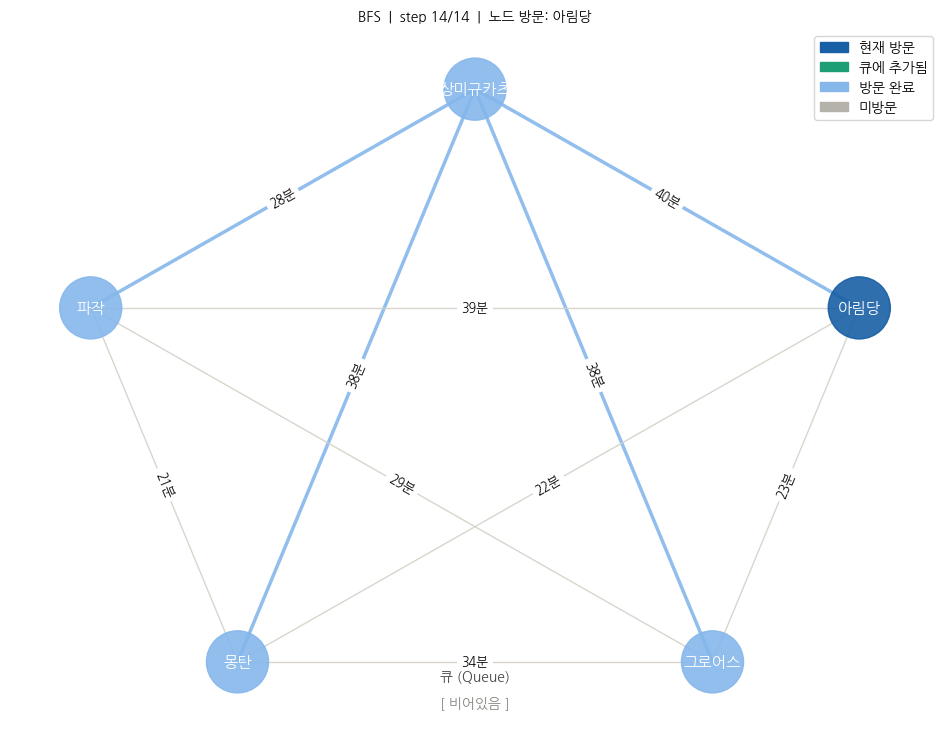

In [ ]:
from collections import deque
import matplotlib.animation as animation
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 9))

def bfs_events(graph, start):
    events = []
    visited_set = set()
    queue = deque([(start, None)])
    visited_set.add(start)

    # 초기 상태 기록
    events.append({
        'type': 'node',
        'node': start,
        'queue_snapshot': list(queue)
    })

    while queue:
        node, from_node = queue.popleft()

        if from_node is not None:
            events.append({
                'type': 'edge',
                'from': from_node,
                'to': node,
                'queue_snapshot': list(queue)
            })

        events.append({
            'type': 'node',
            'node': node,
            'queue_snapshot': list(queue)
        })

        for neighbor in graph.neighbors(node):
            if neighbor not in visited_set:
                visited_set.add(neighbor)
                queue.append((neighbor, node))
                # 큐에 추가될 때마다 스냅샷 저장
                events.append({
                    'type': 'enqueue',
                    'node': neighbor,
                    'queue_snapshot': list(queue)
                })

    return events

events_bfs = bfs_events(G, '상미규카츠')

for i, e in enumerate(events_bfs):
    print(f"[{i}] {e['type']:8s} | 큐: {[n for n, _ in e['queue_snapshot']]}")

def draw_queue(ax, queue_snapshot, fig_width=12):
    """큐를 그래프 하단에 시각화"""
    queue_nodes = [n for n, _ in queue_snapshot]
    n = len(queue_nodes)

    ax.text(0.5, 0.06, '큐 (Queue)', transform=ax.transAxes,
            ha='center', fontsize=10, fontproperties=prop,
            color='#444441')

    if n == 0:
        ax.text(0.5, 0.02, '[ 비어있음 ]', transform=ax.transAxes,
                ha='center', fontsize=10, fontproperties=prop, color='#888780')
        return

    box_w = 0.1
    box_h = 0.05
    total_w = n * box_w + (n - 1) * 0.01
    start_x = 0.5 - total_w / 2

    for i, node in enumerate(queue_nodes):
        x = start_x + i * (box_w + 0.01)
        y = 0.01

        # 박스
        rect = mpatches.FancyBboxPatch(
            (x, y), box_w, box_h,
            boxstyle="round,pad=0.005",
            transform=ax.transAxes,
            facecolor='#B5D4F4', edgecolor='#185FA5', linewidth=1.5,
            clip_on=False
        )
        ax.add_patch(rect)

        # 노드 이름
        ax.text(x + box_w/2, y + box_h/2, node,
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=8, fontproperties=prop, color='#0C447C')

    # HEAD 화살표
    ax.annotate('', xy=(start_x, 0.06),
                xytext=(start_x - 0.05, 0.06),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1.5))
    ax.text(start_x - 0.06, 0.06, 'OUT', transform=ax.transAxes,
            ha='right', va='center', fontsize=8, color='#E24B4A')

    # TAIL 화살표
    tail_x = start_x + total_w
    ax.annotate('', xy=(tail_x, 0.06),
                xytext=(tail_x + 0.05, 0.06),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='<-', color='#1D9E75', lw=1.5))
    ax.text(tail_x + 0.06, 0.06, 'IN', transform=ax.transAxes,
            ha='left', va='center', fontsize=8, color='#1D9E75')

def update_bfs(frame):
    ax.clear()

    ev = events_bfs[frame]

    visited_nodes = set()
    active_edges = set()
    current_node = None
    current_edge = None
    enqueue_node = None

    for i, e in enumerate(events_bfs[:frame+1]):
        if e['type'] == 'node':
            visited_nodes.add(e['node'])
            if i == frame:
                current_node = e['node']
        elif e['type'] == 'edge':
            active_edges.add((e['from'], e['to']))
            if i == frame:
                current_edge = (e['from'], e['to'])
        elif e['type'] == 'enqueue':
            if i == frame:
                enqueue_node = e['node']

    # 노드 색상
    node_colors = []
    for node in G.nodes():
        if node == current_node:
            node_colors.append('#185FA5')
        elif node == enqueue_node:
            node_colors.append('#1D9E75')   # 큐에 막 추가된 노드: 초록
        elif node in visited_nodes:
            node_colors.append('#85B7EB')
        else:
            node_colors.append('#B4B2A9')

    # 간선 색상
    edge_colors = []
    edge_widths = []
    for u, v in G.edges():
        is_current = current_edge and ((u, v) == current_edge or (v, u) == current_edge)
        is_active = (u, v) in active_edges or (v, u) in active_edges
        if is_current:
            edge_colors.append('#185FA5')
            edge_widths.append(4)
        elif is_active:
            edge_colors.append('#85B7EB')
            edge_widths.append(2.5)
        else:
            edge_colors.append('#D3D1C7')
            edge_widths.append(1)

    # 그래프를 위쪽으로 올려서 큐 공간 확보
    pos_shifted = {k: (v[0], v[1] * 0.75 + 0.2) for k, v in pos.items()}

    nx.draw_networkx_nodes(G, pos_shifted, node_color=node_colors, node_size=2000, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos_shifted, font_size=11, font_color='white',
                            font_weight='bold', font_family=prop.get_name(), ax=ax)
    nx.draw_networkx_edges(G, pos_shifted, edge_color=edge_colors, width=edge_widths, alpha=0.9, ax=ax)
    edge_labels = {k: f"{v}분" for k, v in nx.get_edge_attributes(G, 'weight').items()}
    nx.draw_networkx_edge_labels(G, pos_shifted, edge_labels=edge_labels,
                                 font_size=9, font_family=prop.get_name(), ax=ax)

    # 타이틀
    type_str = {
        'node': f"노드 방문: {ev.get('node','')}",
        'edge': f"간선 이동: {ev.get('from','')} → {ev.get('to','')}",
        'enqueue': f"큐에 추가: {ev.get('node','')}",
    }
    ax.set_title(f"BFS  |  step {frame+1}/{len(events_bfs)}  |  {type_str[ev['type']]}",
                 fontsize=13, fontproperties=prop)

    # 큐 시각화
    draw_queue(ax, ev['queue_snapshot'])

    # 범례
    legend = [
        mpatches.Patch(color='#185FA5', label='현재 방문'),
        mpatches.Patch(color='#1D9E75', label='큐에 추가됨'),
        mpatches.Patch(color='#85B7EB', label='방문 완료'),
        mpatches.Patch(color='#B4B2A9', label='미방문'),
    ]
    ax.legend(handles=legend, loc='upper right', prop=prop)
    ax.axis('off')

ani_bfs = animation.FuncAnimation(
    fig, update_bfs,
    frames=len(events_bfs),
    interval=800,
    repeat=False
)

ani_bfs.save('bfs.mp4', writer='ffmpeg', fps=1, dpi=150)
print(f"bfs.mp4 저장 완료! (총 {len(events_bfs)} 프레임)")
plt.show()

#1-4) 프림 애니메이션

[0] start        | MST: []
[1] candidates   | MST: []
[2] select       | MST: []
[3] add          | MST: [('상미규카츠', '파작', 28)]
[4] candidates   | MST: [('상미규카츠', '파작', 28)]
[5] select       | MST: [('상미규카츠', '파작', 28)]
[6] add          | MST: [('상미규카츠', '파작', 28), ('파작', '몽탄', 21)]
[7] candidates   | MST: [('상미규카츠', '파작', 28), ('파작', '몽탄', 21)]
[8] select       | MST: [('상미규카츠', '파작', 28), ('파작', '몽탄', 21)]
[9] add          | MST: [('상미규카츠', '파작', 28), ('파작', '몽탄', 21), ('몽탄', '아림당', 22)]
[10] candidates   | MST: [('상미규카츠', '파작', 28), ('파작', '몽탄', 21), ('몽탄', '아림당', 22)]
[11] select       | MST: [('상미규카츠', '파작', 28), ('파작', '몽탄', 21), ('몽탄', '아림당', 22)]
[12] add          | MST: [('상미규카츠', '파작', 28), ('파작', '몽탄', 21), ('몽탄', '아림당', 22), ('아림당', '그로어스', 23)]
prim.mp4 저장 완료! (총 13 프레임)


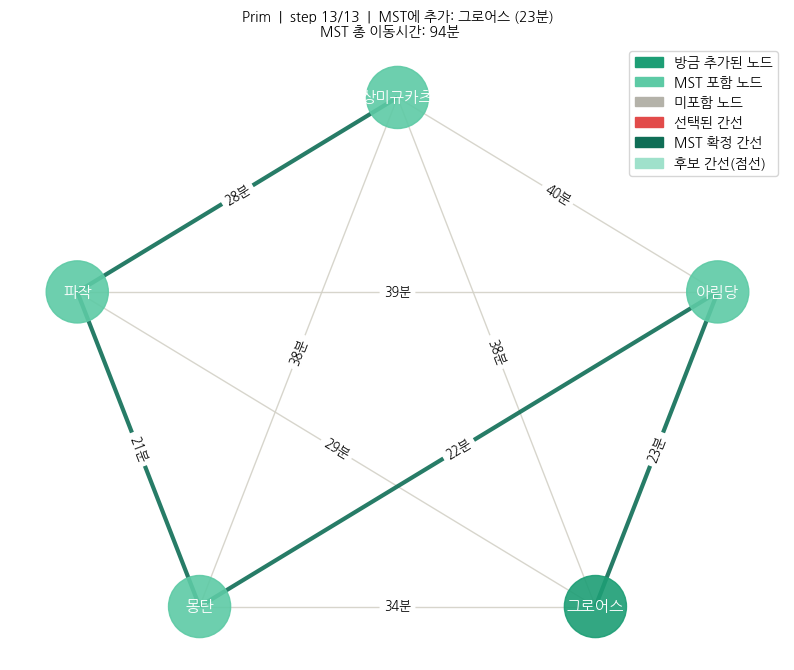

In [ ]:
import matplotlib.animation as animation
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 8))

def prim_events(graph, start):
    events = []
    visited = set([start])
    mst_edges = []

    events.append({
        'type': 'start',
        'node': start,
        'mst_edges': [],
    })

    while len(visited) < len(graph.nodes()):
        candidates = []
        for u in visited:
            for v in graph.neighbors(u):
                if v not in visited:
                    w = graph[u][v]['weight']
                    candidates.append((w, u, v))

        events.append({
            'type': 'candidates',
            'mst_edges': list(mst_edges),
            'candidate_edges': [(u, v, w) for w, u, v in candidates]
        })

        candidates.sort()
        w, u, v = candidates[0]

        events.append({
            'type': 'select',
            'from': u,
            'to': v,
            'weight': w,
            'mst_edges': list(mst_edges),
            'candidate_edges': [(u2, v2, w2) for w2, u2, v2 in candidates]
        })

        mst_edges.append((u, v, w))
        visited.add(v)

        events.append({
            'type': 'add',
            'node': v,
            'from': u,
            'weight': w,
            'mst_edges': list(mst_edges),
            'candidate_edges': []
        })

    return events

events_prim = prim_events(G, '상미규카츠')

for i, e in enumerate(events_prim):
    print(f"[{i}] {e['type']:12s} | MST: {e['mst_edges']}")

def update_prim(frame):
    ax.clear()

    ev = events_prim[frame]
    mst_edges = ev['mst_edges']
    candidate_edges = ev.get('candidate_edges', [])

    # MST 포함 노드
    mst_nodes = set()
    for u, v, w in mst_edges:
        mst_nodes.add(u)
        mst_nodes.add(v)
    if ev['type'] == 'start':
        mst_nodes.add(ev['node'])

    mst_edge_set = {(u, v) for u, v, w in mst_edges} | {(v, u) for u, v, w in mst_edges}
    candidate_edge_set = {(u, v) for u, v, w in candidate_edges} | {(v, u) for u, v, w in candidate_edges}

    select_edge = None
    if ev['type'] == 'select':
        select_edge = (ev['from'], ev['to'])

    # 노드 색상
    node_colors = []
    for node in G.nodes():
        if ev['type'] == 'add' and node == ev.get('node'):
            node_colors.append('#1D9E75')
        elif node in mst_nodes:
            node_colors.append('#5DCAA5')
        else:
            node_colors.append('#B4B2A9')

    # 간선 색상
    edge_colors = []
    edge_widths = []
    edge_styles = []
    for u, v in G.edges():
        in_mst = (u, v) in mst_edge_set
        is_select = select_edge and ((u, v) == select_edge or (v, u) == select_edge)
        is_candidate = (u, v) in candidate_edge_set

        if is_select:
            edge_colors.append('#E24B4A')
            edge_widths.append(4)
            edge_styles.append('solid')
        elif in_mst:
            edge_colors.append('#0F6E56')
            edge_widths.append(3)
            edge_styles.append('solid')
        elif is_candidate:
            edge_colors.append('#9FE1CB')
            edge_widths.append(1.5)
            edge_styles.append('dashed')
        else:
            edge_colors.append('#D3D1C7')
            edge_widths.append(1)
            edge_styles.append('solid')

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=11, font_color='white',
                            font_weight='bold', font_family=prop.get_name(), ax=ax)

    for style in ['solid', 'dashed']:
        style_edges = [(u, v) for (u, v), s in zip(G.edges(), edge_styles) if s == style]
        style_colors = [c for c, s in zip(edge_colors, edge_styles) if s == style]
        style_widths = [w for w, s in zip(edge_widths, edge_styles) if s == style]
        if style_edges:
            nx.draw_networkx_edges(G, pos, edgelist=style_edges,
                                   edge_color=style_colors, width=style_widths,
                                   style=style, alpha=0.9, ax=ax)

    edge_labels = {k: f"{v}분" for k, v in nx.get_edge_attributes(G, 'weight').items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=9, font_family=prop.get_name(), ax=ax)

    # 후보 간선 목록을 타이틀 아래 텍스트로 표시
    type_str = {
        'start':      f"시작 노드: {ev.get('node', '')}",
        'candidates': f"후보 간선 탐색 중",
        'select':     f"최소 간선 선택: {ev.get('from', '')} ↔ {ev.get('to', '')} ({ev.get('weight', '')}분)",
        'add':        f"MST에 추가: {ev.get('node', '')} ({ev.get('weight', '')}분)",
    }
    total_w = sum(w for _, _, w in mst_edges)

    # 후보 간선 텍스트 한 줄로
    if candidate_edges:
        sorted_c = sorted(candidate_edges, key=lambda x: x[2])
        cand_str = '  |  '.join([f"{u}↔{v} {w}분" for u, v, w in sorted_c])
        cand_text = f"후보: {cand_str}"
    else:
        cand_text = ""

    ax.set_title(
        f"Prim  |  step {frame+1}/{len(events_prim)}  |  {type_str[ev['type']]}\n"
        f"MST 총 이동시간: {total_w}분    {cand_text}",
        fontsize=10, fontproperties=prop
    )

    legend = [
        mpatches.Patch(color='#1D9E75', label='방금 추가된 노드'),
        mpatches.Patch(color='#5DCAA5', label='MST 포함 노드'),
        mpatches.Patch(color='#B4B2A9', label='미포함 노드'),
        mpatches.Patch(color='#E24B4A', label='선택된 간선'),
        mpatches.Patch(color='#0F6E56', label='MST 확정 간선'),
        mpatches.Patch(color='#9FE1CB', label='후보 간선(점선)'),
    ]
    ax.legend(handles=legend, loc='upper right', prop=prop, fontsize=8)
    ax.axis('off')

ani_prim = animation.FuncAnimation(
    fig, update_prim,
    frames=len(events_prim),
    interval=1000,
    repeat=False
)

ani_prim.save('prim.mp4', writer='ffmpeg', fps=1, dpi=150)
print(f"prim.mp4 저장 완료! (총 {len(events_prim)} 프레임)")
plt.show()

#1-5) 크루스칼 애니메이션

[0] start    | 현재간선: None | MST: []
[1] check    | 현재간선: ('파작', '몽탄', 21) | MST: []
[2] accept   | 현재간선: ('파작', '몽탄', 21) | MST: [('파작', '몽탄', 21)]
[3] check    | 현재간선: ('몽탄', '아림당', 22) | MST: [('파작', '몽탄', 21)]
[4] accept   | 현재간선: ('몽탄', '아림당', 22) | MST: [('파작', '몽탄', 21), ('몽탄', '아림당', 22)]
[5] check    | 현재간선: ('그로어스', '아림당', 23) | MST: [('파작', '몽탄', 21), ('몽탄', '아림당', 22)]
[6] accept   | 현재간선: ('그로어스', '아림당', 23) | MST: [('파작', '몽탄', 21), ('몽탄', '아림당', 22), ('그로어스', '아림당', 23)]
[7] check    | 현재간선: ('상미규카츠', '파작', 28) | MST: [('파작', '몽탄', 21), ('몽탄', '아림당', 22), ('그로어스', '아림당', 23)]
[8] accept   | 현재간선: ('상미규카츠', '파작', 28) | MST: [('파작', '몽탄', 21), ('몽탄', '아림당', 22), ('그로어스', '아림당', 23), ('상미규카츠', '파작', 28)]
[9] done     | 현재간선: None | MST: [('파작', '몽탄', 21), ('몽탄', '아림당', 22), ('그로어스', '아림당', 23), ('상미규카츠', '파작', 28)]


/tmp/ipykernel_1886/1776235554.py:200: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) NanumGothic.
  ani_kruskal.save('kruskal.mp4', writer='ffmpeg', fps=1, dpi=150)


kruskal.mp4 저장 완료! (총 10 프레임)


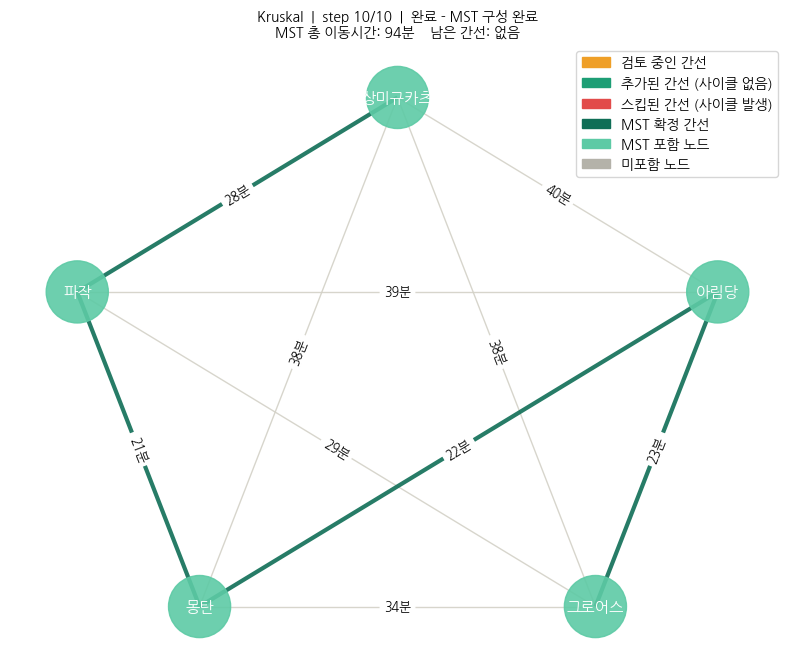

In [ ]:
import matplotlib.animation as animation
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 8))

def kruskal_events(graph):
    events = []

    all_edges = sorted(
        [(w, u, v) for u, v, w in graph.edges.data('weight')],
        key=lambda x: x[0]
    )

    parent = {node: node for node in graph.nodes()}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        parent[find(x)] = find(y)

    mst_edges = []

    events.append({
        'type': 'start',
        'mst_edges': [],
        'remaining_edges': [(u, v, w) for w, u, v in all_edges],
        'current_edge': None,
    })

    for w, u, v in all_edges:
        events.append({
            'type': 'check',
            'current_edge': (u, v, w),
            'mst_edges': list(mst_edges),
            'remaining_edges': [(u2, v2, w2) for w2, u2, v2 in all_edges
                                if (u2, v2, w2) not in mst_edges],
        })

        if find(u) != find(v):
            union(u, v)
            mst_edges.append((u, v, w))
            events.append({
                'type': 'accept',
                'current_edge': (u, v, w),
                'mst_edges': list(mst_edges),
                'remaining_edges': [(u2, v2, w2) for w2, u2, v2 in all_edges
                                    if (u2, v2, w2) not in mst_edges],
            })
        else:
            events.append({
                'type': 'reject',
                'current_edge': (u, v, w),
                'mst_edges': list(mst_edges),
                'remaining_edges': [(u2, v2, w2) for w2, u2, v2 in all_edges
                                    if (u2, v2, w2) not in mst_edges],
            })

        if len(mst_edges) == len(graph.nodes()) - 1:
            break

    events.append({
        'type': 'done',
        'mst_edges': list(mst_edges),
        'current_edge': None,
        'remaining_edges': [],
    })

    return events

events_kruskal = kruskal_events(G)

for i, e in enumerate(events_kruskal):
    print(f"[{i}] {e['type']:8s} | 현재간선: {e['current_edge']} | MST: {e['mst_edges']}")

def update_kruskal(frame):
    ax.clear()

    ev = events_kruskal[frame]
    mst_edges = ev['mst_edges']
    current_edge = ev.get('current_edge')

    mst_edge_set = {(u, v) for u, v, w in mst_edges} | {(v, u) for u, v, w in mst_edges}

    mst_nodes = set()
    for u, v, w in mst_edges:
        mst_nodes.add(u)
        mst_nodes.add(v)

    # 노드 색상
    node_colors = []
    for node in G.nodes():
        if current_edge and node in (current_edge[0], current_edge[1]):
            if ev['type'] == 'reject':
                node_colors.append('#E24B4A')
            elif ev['type'] == 'accept':
                node_colors.append('#1D9E75')
            else:
                node_colors.append('#EF9F27')
        elif node in mst_nodes:
            node_colors.append('#5DCAA5')
        else:
            node_colors.append('#B4B2A9')

    # 간선 색상
    edge_colors = []
    edge_widths = []
    edge_styles = []
    for u, v in G.edges():
        in_mst = (u, v) in mst_edge_set
        is_current = current_edge and (
            (u == current_edge[0] and v == current_edge[1]) or
            (u == current_edge[1] and v == current_edge[0])
        )

        if is_current:
            if ev['type'] == 'reject':
                edge_colors.append('#E24B4A')
                edge_styles.append('dashed')
            elif ev['type'] == 'accept':
                edge_colors.append('#1D9E75')
                edge_styles.append('solid')
            else:
                edge_colors.append('#EF9F27')
                edge_styles.append('solid')
            edge_widths.append(4)
        elif in_mst:
            edge_colors.append('#0F6E56')
            edge_widths.append(3)
            edge_styles.append('solid')
        else:
            edge_colors.append('#D3D1C7')
            edge_widths.append(1)
            edge_styles.append('solid')

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=11, font_color='white',
                            font_weight='bold', font_family=prop.get_name(), ax=ax)

    for style in ['solid', 'dashed']:
        style_edges = [(u, v) for (u, v), s in zip(G.edges(), edge_styles) if s == style]
        style_colors = [c for c, s in zip(edge_colors, edge_styles) if s == style]
        style_widths = [w for w, s in zip(edge_widths, edge_styles) if s == style]
        if style_edges:
            nx.draw_networkx_edges(G, pos, edgelist=style_edges,
                                   edge_color=style_colors, width=style_widths,
                                   style=style, alpha=0.9, ax=ax)

    edge_labels = {k: f"{v}분" for k, v in nx.get_edge_attributes(G, 'weight').items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=9, font_family=prop.get_name(), ax=ax)

    # 타이틀 (current_edge가 None인 경우 안전하게 처리)
    if ev['type'] == 'start':
        title_detail = "시작 - 간선을 가중치 오름차순 정렬"
    elif ev['type'] == 'check':
        title_detail = f"검토: {current_edge[0]} ↔ {current_edge[1]} ({current_edge[2]}분) - 사이클 확인 중"
    elif ev['type'] == 'accept':
        title_detail = f"추가: {current_edge[0]} ↔ {current_edge[1]} ({current_edge[2]}분) - 사이클 없음 ✓"
    elif ev['type'] == 'reject':
        title_detail = f"스킵: {current_edge[0]} ↔ {current_edge[1]} ({current_edge[2]}분) - 사이클 발생 ✗"
    else:
        title_detail = "완료 - MST 구성 완료"

    total_w = sum(w for _, _, w in mst_edges)
    remaining = ev.get('remaining_edges', [])
    if remaining:
        sorted_r = sorted(remaining, key=lambda x: x[2])
        remain_text = "남은 간선: " + '  |  '.join([f"{u}↔{v} {w}분" for u, v, w in sorted_r])
    else:
        remain_text = "남은 간선: 없음"

    ax.set_title(
        f"Kruskal  |  step {frame+1}/{len(events_kruskal)}  |  {title_detail}\n"
        f"MST 총 이동시간: {total_w}분    {remain_text}",
        fontsize=10, fontproperties=prop
    )

    legend = [
        mpatches.Patch(color='#EF9F27', label='검토 중인 간선'),
        mpatches.Patch(color='#1D9E75', label='추가된 간선 (사이클 없음)'),
        mpatches.Patch(color='#E24B4A', label='스킵된 간선 (사이클 발생)'),
        mpatches.Patch(color='#0F6E56', label='MST 확정 간선'),
        mpatches.Patch(color='#5DCAA5', label='MST 포함 노드'),
        mpatches.Patch(color='#B4B2A9', label='미포함 노드'),
    ]
    ax.legend(handles=legend, loc='upper right', prop=prop, fontsize=8)
    ax.axis('off')

ani_kruskal = animation.FuncAnimation(
    fig, update_kruskal,
    frames=len(events_kruskal),
    interval=1000,
    repeat=False
)

ani_kruskal.save('kruskal.mp4', writer='ffmpeg', fps=1, dpi=150)
print(f"kruskal.mp4 저장 완료! (총 {len(events_kruskal)} 프레임)")
plt.show()